In [1]:
# Import the necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset into a Pandas Dataframe
df = pd.read_csv("data.csv")

In [3]:
# Check the first five rows of the dataset
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,5/2/2014 0:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,5/2/2014 0:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,5/2/2014 0:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,5/2/2014 0:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,5/2/2014 0:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
# Check the last five rows
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4595,7/9/2014 0:00,308166.6667,3,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,7/9/2014 0:00,534333.3333,3,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,7/9/2014 0:00,416904.1667,3,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,7/10/2014 0:00,203400.0000,4,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4599,7/10/2014 0:00,220600.0000,3,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


In [5]:
# Brief Statistiscal Summary of the Dataset
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
df.sort_values(by='price', ascending=True)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4472,6/9/2014 0:00,0.0,4,3.75,4060,19290,2.0,0,0,3,4060,0,2002,0,21418 SE 5th Pl,Sammamish,WA 98074,USA
4542,6/25/2014 0:00,0.0,5,3.50,2640,6895,2.0,0,0,3,2640,0,2001,0,34529 SE Jay Ct,Snoqualmie,WA 98065,USA
4481,6/11/2014 0:00,0.0,5,2.75,3240,6863,2.0,0,0,3,3240,0,2013,1923,1301-1303 Monterey Ave NE,Renton,WA 98056,USA
4408,5/21/2014 0:00,0.0,5,2.25,2880,11965,2.0,0,0,4,2880,0,1990,0,25437 163rd Pl SE,Covington,WA 98042,USA
4411,5/22/2014 0:00,0.0,5,2.25,2000,7900,1.0,0,0,4,1300,700,1986,0,3202 S 194th St,SeaTac,WA 98188,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2761,6/18/2014 0:00,4489000.0,4,3.00,6430,27517,2.0,0,0,3,6430,0,2001,0,1149-1199 91st Ave NE,Bellevue,WA 98004,USA
2654,6/17/2014 0:00,4668000.0,5,6.75,9640,13068,1.0,1,4,3,4820,4820,1983,2009,5044 Butterworth Rd,Mercer Island,WA 98040,USA
2286,6/11/2014 0:00,7062500.0,5,4.50,10040,37325,2.0,1,2,3,7680,2360,1940,2001,4442 95th Ave NE,Bellevue,WA 98004,USA
4346,6/23/2014 0:00,12899000.0,3,2.50,2190,11394,1.0,0,0,3,1550,640,1956,2001,5426 40th Ave W,Seattle,WA 98199,USA


In [7]:
(df['price'] == 0).sum()

np.int64(49)

In [8]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [9]:
# Detect how many houses have the price to be 0
(df['price'] <= 0).sum()

np.int64(49)

In [10]:
# Check for Muticolinearity using correlation matrix
print(df.info())
num_cols = df.select_dtypes(include=[np.number])
num_cols.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

In [11]:
df['date'] = pd.to_datetime(df['date'])
df['date']

0      2014-05-02
1      2014-05-02
2      2014-05-02
3      2014-05-02
4      2014-05-02
          ...    
4595   2014-07-09
4596   2014-07-09
4597   2014-07-09
4598   2014-07-10
4599   2014-07-10
Name: date, Length: 4600, dtype: datetime64[ns]

In [12]:
correlation_matrix = num_cols.corr()
correlation_matrix

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


<Axes: >

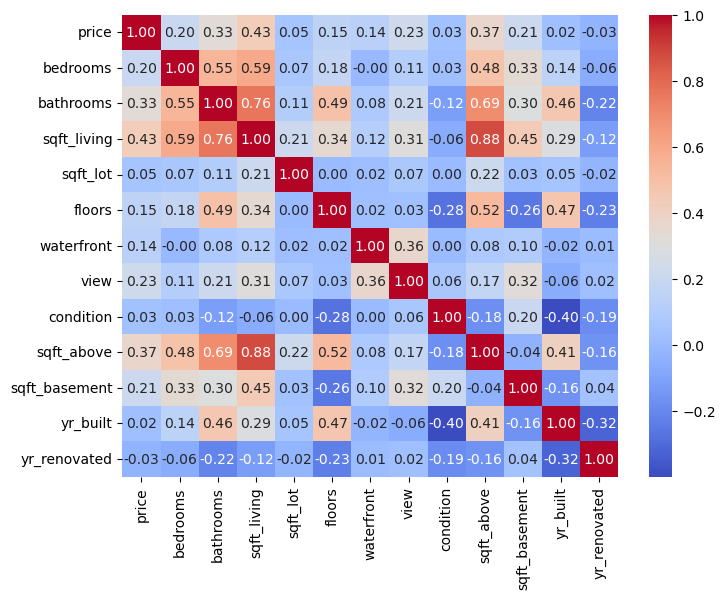

In [13]:
# Plot the Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

In [14]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [15]:
cols_to_drop = ['sqft_lot', 'sqft_above', 'sqft_basement', 'street', 
               'city', 'statezip', 'country', 'date']

df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,yr_built,yr_renovated
0,313000.0,3,1.50,1340,1.5,0,0,3,1955,2005
1,2384000.0,5,2.50,3650,2.0,0,4,5,1921,0
2,342000.0,3,2.00,1930,1.0,0,0,4,1966,0
3,420000.0,3,2.25,2000,1.0,0,0,4,1963,0
4,550000.0,4,2.50,1940,1.0,0,0,4,1976,1992


In [16]:
(df_cleaned['yr_renovated'] <= 0).sum()

np.int64(2735)

In [17]:
(df_cleaned['price'] <= 0).sum()

np.int64(49)

In [18]:
df_cleaned_final = df_cleaned[df_cleaned['price'] > 0]
df_cleaned_final = df_cleaned_final.drop(columns=['yr_renovated'])

In [19]:
df_cleaned_final.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,yr_built
0,313000.0,3,1.50,1340,1.5,0,0,3,1955
1,2384000.0,5,2.50,3650,2.0,0,4,5,1921
2,342000.0,3,2.00,1930,1.0,0,0,4,1966
3,420000.0,3,2.25,2000,1.0,0,0,4,1963
4,550000.0,4,2.50,1940,1.0,0,0,4,1976


In [20]:
(df_cleaned_final['price'] <= 0).sum()

np.int64(0)

In [21]:
len(df) 

4600

In [22]:
len(df_cleaned_final)

4551

## Data Splitting

In [23]:
# Separate the Target from the Features
X = df_cleaned_final.drop(columns='price')
y = df_cleaned_final['price']

In [24]:
# Split the dataset into train and test(80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [25]:
# Normalization
# !!!! ALways nofrom sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [26]:
# Instantiate the Linear Regression Model
lr = LinearRegression()
# TRain the model on the training dataset
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# Make Preditions
y_pred = lr.predict(X_test)

In [28]:
# Evaluate the model
mae_score = mean_absolute_error(y_test, y_pred)
mse_score = mean_squared_error(y_test, y_pred)
#rmse
rmse_score = mse_score ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae_score:.4f}')
print('MSE Score: ', mse_score)
print(f'RMSE Score: {rmse_score:.4f}')
print('R2_Score:', r2)

Mean Absolute Error: 160795.2942
MSE Score:  60065189633.13607
RMSE Score: 245082.0059
R2_Score: 0.5962557511946713


In [29]:
print(X_train.shape)
print(y_train.shape)

(3640, 8)
(3640,)


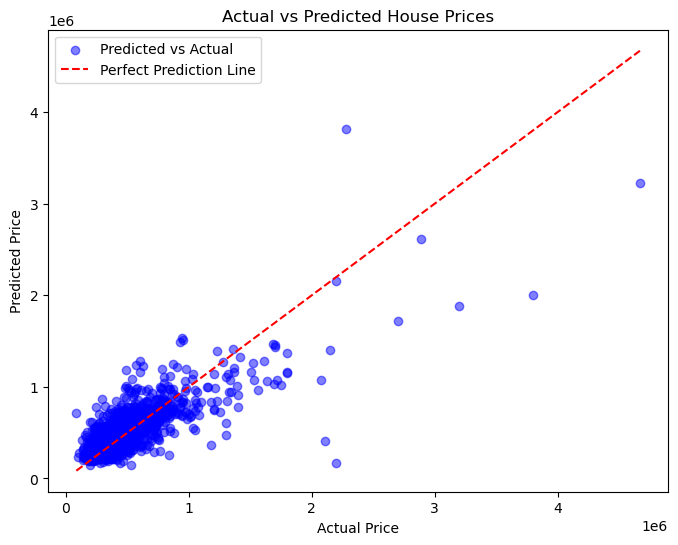

In [30]:
# Line of Best Fit
# Scatter Plot

# Actual vs Predicted - Scatter Plot

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')

# Perfect diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.show()

